<a href="https://colab.research.google.com/github/athifaahnr/tokopedia-sentiment-analysis/blob/main/sentiment_analysis_tokopedia_projek_akhir_vinix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tahap 1: Persiapan Data & Serialisasi Model

###Instalasi Library yang Dibutuhkan

In [ ]:
!pip install kaggle streamlit pyngrok scikit-learn pandas numpy matplotlib seaborn wordcloud -q

print("✅ Semua library berhasil diinstal dengan sukses!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.0 MB/s eta 0:00:00
✅ Semua library berhasil diinstal dengan sukses!


### Setup Kaggle API & Download Dataset di Kaggle

In [ ]:
import os
import json
from getpass import getpass

# Memeriksa apakah user menggunakan fitur Colab Secrets atau input manual
try:
    from google.colab import userdata
    KAGGLE_USER = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY = userdata.get('KAGGLE_KEY')
except Exception:
    KAGGLE_USER = None
    KAGGLE_KEY = None

# Jika tidak diset di Secrets Colab, minta input interaktif yang aman (tidak tampil di layar)
if not KAGGLE_USER or not KAGGLE_KEY:
    print("🔑 Masukkan kredensial Kaggle Anda (Bisa didapat dari Kaggle -> Account -> Create New API Token):")
    KAGGLE_USER = input("Masukkan Kaggle Username: ")
    KAGGLE_KEY = getpass("Masukkan Kaggle API Key: ")

kaggle_credentials = {
    "username": KAGGLE_USER,
    "key": KAGGLE_KEY
}

# Simpan ke lokasi yang dikenali oleh sistem Kaggle
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
cfg_path = os.path.join(kaggle_dir, "kaggle.json")

with open(cfg_path, "w") as f:
    json.dump(kaggle_credentials, f)

os.chmod(cfg_path, 600)
print("✅ Kredensial Kaggle berhasil disimpan dengan aman tanpa hardcoding!")

🔑 Masukkan kredensial Kaggle Anda (Bisa didapat dari Kaggle -> Account -> Create New API Token):
Masukkan Kaggle Username: athifahnr
Masukkan Kaggle API Key: ··········
✅ Kredensial Kaggle berhasil disimpan dengan aman tanpa hardcoding!


In [ ]:
# Download dataset Tokopedia secara otomatis ke direktori target
!kaggle datasets download -d salmanabdu/tokopedia-product-reviews-2025 --unzip -p /content/data/

# Tampilkan isi folder untuk memastikan file berhasil diunduh
import os
print("Isi direktori data:")
for f in os.listdir("/content/data/"):
    print(f"- {f}")

Dataset URL: https://www.kaggle.com/datasets/salmanabdu/tokopedia-product-reviews-2025
License(s): MIT
100% 3.54M/3.54M [00:00<00:00, 181MB/s]

Isi direktori data:
- tokopedia_product_reviews_2025.csv


### Eksplorasi Data Awal (EDA)

In [ ]:
import pandas as pd
import glob
import warnings
warnings.filterwarnings('ignore')

# Mendeteksi file CSV secara dinamis
csv_files = glob.glob("/content/data/*.csv")
if not csv_files:
    raise FileNotFoundError("Waduhhhh, file CSV tidak ditemukan. Periksa kembali proses download.")

df = pd.read_csv(csv_files[0])

print(f"Dimensi Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("--- 5 Baris Pertama Dataset ---")
display(df.head())
print("\n--- Ringkasan Struktur Kolom ---")
print(df.info())
print("\n--- Jumlah Nilai Hilang (Missing Values) ---")
print(df.isnull().sum())

Dimensi Dataset: 65543 baris, 13 kolom

--- 5 Baris Pertama Dataset ---


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive



--- Ringkasan Struktur Kolom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB
None

--- Jumlah Nilai Hilang (Missing Values) ---
review_text             0
review_date             0
review_id     

### Pra-pemrosesan Data & Pelabelan Sentimen

In [ ]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# TAHAP 1.5 — Pembersihan Teks Nyata & Balanced Sampling
# ============================================================

# Pastikan TEXT_COL terdefinisi dengan benar
if 'TEXT_COL' not in locals() and 'TEXT_COL' not in globals():
    TEXT_COL = 'review_text'  # Default sesuai dataset

# Cek & Amankan Nama Kolom Sentimen (Bisa 'Sentimen' atau 'sentimen') ---
if 'Sentimen' in df.columns:
    SENTIMEN_COL = 'Sentimen'
elif 'sentimen' in df.columns:
    SENTIMEN_COL = 'sentimen'
else:
    # Jika ternyata kolom sentimen belum dibuat sama sekali, kita buat otomatis di sini
    print("Kolom sentimen belum ditemukan. Membuat kolom 'Sentimen' otomatis dari rating...")
    RATING_COL = 'rating' if 'rating' in df.columns else 'score'

    def tentukan_sentimen(rating):
        if rating > 3: return 'Positif'
        elif rating < 3: return 'Negatif'
        else: return 'Netral'

    df['Sentimen'] = pd.to_numeric(df[RATING_COL], errors='coerce').apply(tentukan_sentimen)
    SENTIMEN_COL = 'Sentimen'

print(f"Menggunakan kolom teks: '{TEXT_COL}' dan kolom sentimen: '{SENTIMEN_COL}'")

# 1. Definisikan Fungsi Pembersihan Teks yang Dioptimalkan
def clean_text_pro(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # Hapus URL bikos tdk mengandung yg dibutuhkan(emosi/sentimen dlm belanja)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)         # Hapus angka & simbol yg tersisa huruf A-Z aja
    text = re.sub(r'\s+', ' ', text).strip()         # Menghapus spasi ganda

    # Hapus token kata pendek (< 2 karakter)
    text = ' '.join([word for word in text.split() if len(word) >= 2])
    return text

# Terapkan pembersihan teks
df['review_clean'] = df[TEXT_COL].apply(clean_text_pro)

# 2. Singkirkan baris kosong / ulasan bising (hanya berisi emoji/spasi sebelum dibersihkan)
df = df[df['review_clean'].str.len() > 5]

# 3. Balanced Sampling — menggantikan Stratified Sampling sebelumnya
# Alasan perubahan: dataset asli sangat timpang (97.5% Positif vs 1.2% Negatif & Netral).
# Stratified sampling mempertahankan ketimpangan tersebut ke df_sample sehingga model
# menjadi bias total ke kelas Positif (F1-Macro hanya 0.35).
# Solusi: ambil jumlah data yang seimbang per kelas agar model dapat belajar dari
# ketiga sentimen secara adil.

# Hitung jumlah data minoritas yang benar-benar tersedia setelah proses cleaning
# agar tidak melebihi batas data yang ada (mencegah error saat .sample())
jumlah_per_kelas = min(
    len(df[df[SENTIMEN_COL] == 'Negatif']),
    len(df[df[SENTIMEN_COL] == 'Netral'])
)

# Batasi maksimal 700 per kelas — cukup banyak untuk model belajar,
# tanpa menghabiskan seluruh data minoritas yang tersedia
SAMPLE_PER_CLASS = min(jumlah_per_kelas, 700)

print(f"Jumlah data minoritas tersedia setelah cleaning: {jumlah_per_kelas} baris")
print(f"SAMPLE_PER_CLASS yang digunakan: {SAMPLE_PER_CLASS} baris per kelas\n")

df_positif = df[df[SENTIMEN_COL] == 'Positif'].sample(n=SAMPLE_PER_CLASS, random_state=42)
df_negatif = df[df[SENTIMEN_COL] == 'Negatif'].sample(n=SAMPLE_PER_CLASS, random_state=42)
df_netral  = df[df[SENTIMEN_COL] == 'Netral'].sample(n=SAMPLE_PER_CLASS, random_state=42)

# Gabungkan dan acak urutannya
df_sample = pd.concat([df_positif, df_negatif, df_netral])
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Berhasil melakukan Balanced Sampling menjadi {len(df_sample):,} baris.")

print("\nDistribusi Kelas Hasil Sampling Menyeluruh:")
print(df_sample[SENTIMEN_COL].value_counts())
print()
print(df_sample[SENTIMEN_COL].value_counts(normalize=True) * 100)

Kolom sentimen belum ditemukan. Membuat kolom 'Sentimen' otomatis dari rating...
Menggunakan kolom teks: 'review_text' dan kolom sentimen: 'Sentimen'
Jumlah data minoritas tersedia setelah cleaning: 791 baris
SAMPLE_PER_CLASS yang digunakan: 700 baris per kelas

Berhasil melakukan Balanced Sampling menjadi 2,100 baris.

Distribusi Kelas Hasil Sampling Menyeluruh:
Sentimen
Negatif    700
Positif    700
Netral     700
Name: count, dtype: int64

Sentimen
Negatif    33.333333
Positif    33.333333
Netral     33.333333
Name: proportion, dtype: float64


cell diatas: Cell kode ini melakukan pra-pemrosesan data secara komprehensif. Pertama, kode melakukan validasi ketersediaan kolom teks dan sentimen secara dinamis (defensive programming). Kedua, teks ulasan dibersihkan dari noise (URL, angka, simbol, dan token satu huruf) menggunakan Regular Expression (RegEx). Ketiga, ulasan bising yang terlalu pendek disaring untuk menghindari string kosong. Terakhir, dilakukan stratified sampling menggunakan Scikit-Learn guna mereduksi data menjadi 10.000 baris dengan tetap mempertahankan rasio sebaran kelas asli secara presisi sebelum masuk ke tahap training model

In [ ]:
print("=== Distribusi di Dataset ASLI (df) ===")
print(df[SENTIMEN_COL].value_counts())
print()
print(df[SENTIMEN_COL].value_counts(normalize=True) * 100)

=== Distribusi di Dataset ASLI (df) ===
Sentimen
Positif    62184
Negatif      791
Netral       791
Name: count, dtype: int64

Sentimen
Positif    97.519054
Negatif     1.240473
Netral      1.240473
Name: proportion, dtype: float64


In [ ]:
# ============================================================
#  SIMULASI UJI COBA INPUT MANUAL (CUSTOM)
# ============================================================
print("\nDistribusi Kelas Setelah Sampling (Jumlah Data):")
print(df_sample[SENTIMEN_COL].value_counts())

print("\nPerbandingan Hasil Pembersihan Teks (Simulasi Input Manual):")

# Tulis teks kotor yang ingin kamu uji di sini
teks_input_kamu = "Barang BAGUS bgt!!!  SESUAI HARga 100% lancar di www.tokopedia.com x"

# Jalankan fungsi pembersih teks
teks_hasil_clean = clean_text_pro(teks_input_kamu)

# Tampilkan hasil perbandingan ke layar
print(f"SEBELUM Cleaning : \"{teks_input_kamu}\"")
print(f"SETELAH Cleaning : \"{teks_hasil_clean}\"")


Distribusi Kelas Setelah Sampling (Jumlah Data):
Sentimen
Negatif    700
Positif    700
Netral     700
Name: count, dtype: int64

Perbandingan Hasil Pembersihan Teks (Simulasi Input Manual):
SEBELUM Cleaning : "Barang BAGUS bgt!!!  SESUAI HARga 100% lancar di www.tokopedia.com x"
SETELAH Cleaning : "barang bagus bgt sesuai harga lancar di"


cell diatas: untuk membuktikan fungsi data cleansing berjalan dengan baik, saya melakukan unit testing menggunakan sebuah string acak yang sengaja diisi dengan gangguan data (noise). Hasil pengujian menunjukkan huruf kapital berhasil dikecilkan, tanda seru dan emoji dihapus, angka '100%' dihilangkan, URL Tokopedia dibuang, dan karakter 'x' di akhir dihapus karena panjangnya kurang dari 2 karakter. Ini memastikan data yang masuk ke model Naive Bayes nantinya benar-benar bersih

### Visualisasi Distribusi Kelas

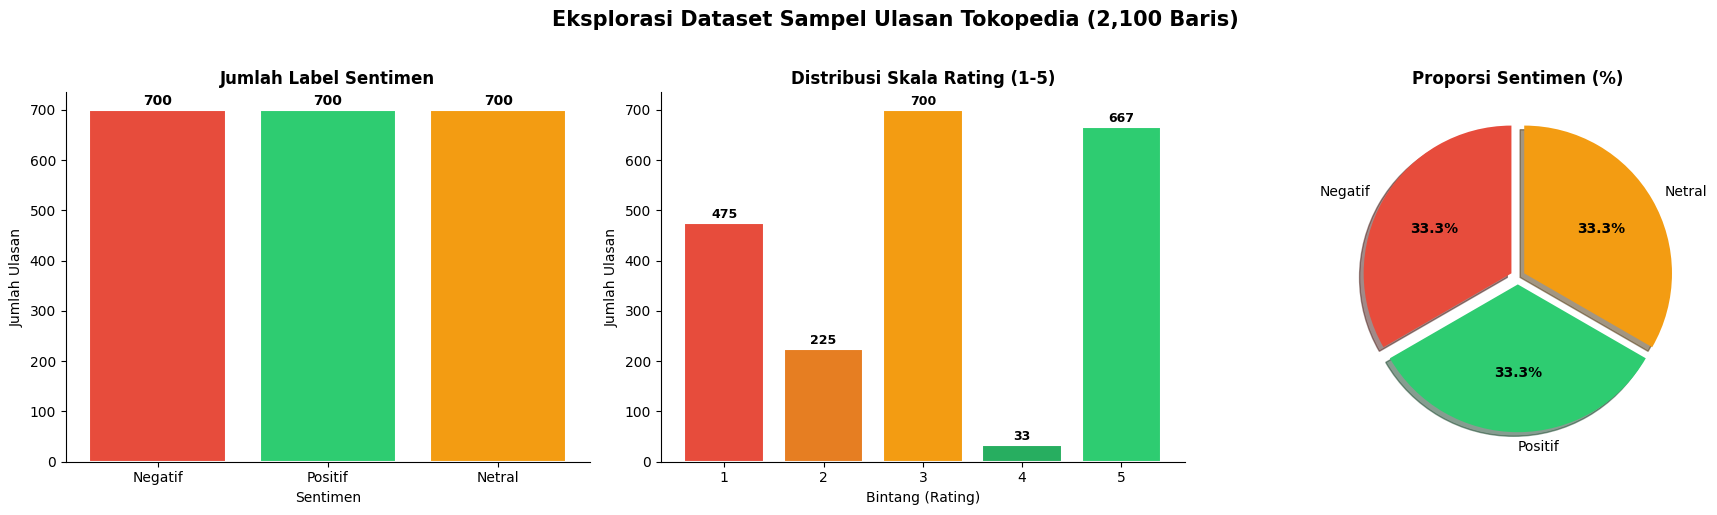

Visualisasi EDA data sampel berhasil dibuat dan disimpan: /content/eda_sentimen_sample.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# TAHAP 1.6 — Eksplorasi Data & Visualisasi (Data Sampel)
# ============================================================

# Membuat kanvas dengan 3 subplot (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Eksplorasi Dataset Sampel Ulasan Tokopedia ({len(df_sample):,} Baris)', fontsize=15, fontweight='bold', y=1.02)
# Mengunci tema warna sentimen agar seragam di semua grafik
warna_sentimen = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#f39c12'} #hijau-red-orange

# ============================================================
# --- PLOT 1: Distribusi Jumlah Sentimen (Bar Chart Kiri) ---
# ============================================================
counts_sentimen = df_sample[SENTIMEN_COL].value_counts() # Menghitung jumlah data per kelompok sentimen (Pos brp, Neg brpa, Net brp)
bars1 = axes[0].bar(
    counts_sentimen.index,
    counts_sentimen.values,
    color=[warna_sentimen.get(c, '#95a5a6') for c in counts_sentimen.index], #list comprehension utk cocokkan nm sentimen dgn kmus warna
    edgecolor='white', linewidth=1.5 #gris tepi
)
# Mengatur judul, label sumbu X, dan label sumbu Y khusus untuk grafik pertama (axes[0])
axes[0].set_title('Jumlah Label Sentimen', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Ulasan')
#.spines adalah garis bingkai kotak grafik. disini disembunyikan bingkai bagian atas dan kanan spy estetik
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Melakukan perulangan utk mengambil setiap batang pada grafik guna ditempeli angka dengan format ribuan
for bar in bars1:
    yval = bar.get_height() # Mengambil tinggi batang (ini jumlah data konkritnya)
    # menentukan posisi koordinat teks angka. utk posisi X koordinat awal btang +lebar btg/2 agar teksnya itu ada di tengah" batang.
    # utk posisi Y, tinggi+sedikit jarak(0.05% dr nilai max data) spy teks tdk nempel pas diujung batang
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + (max(counts_sentimen.values)*0.005),
                 f'{int(yval):,}', ha='center', va='bottom', fontweight='bold', fontsize=10) # f'{int(yval):,}' artinya: ubah angka jadi bilangan bulat (int), lalu beri format tanda koma sebagai pemisah ribuan


# ============================================================
# --- PLOT 2: Distribusi Rating Asli (Bar Chart Tengah) ---
# ============================================================
# Mengamankan nama kolom rating/score di dalam df_sample
rating_col_real = RATING_COL if RATING_COL in df_sample.columns else ('rating' if 'rating' in df_sample.columns else 'score')
rating_counts = df_sample[rating_col_real].value_counts().sort_index() #bintang ulasan terkecil ke terbesar

# Degradasi warna dari Rating 1 (Merah) sampai Rating 5 (Hijau)
warna_rating = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71']

bars2 = axes[1].bar(
    rating_counts.index.astype(str), # Mengubah angka index menjadi teks spy rapih susunannya
    rating_counts.values,
    color=warna_rating[:len(rating_counts)], # menyesuaikan jumlah warna yang akan digunakan agar pas dengan jumlah batang grafik yang akan digambar
    edgecolor='white', linewidth=1.5
)

# Mengatur judul dan label sumbu khusus untuk grafik kedua (axes[1])
axes[1].set_title('Distribusi Skala Rating (1-5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Bintang (Rating)')
axes[1].set_ylabel('Jumlah Ulasan')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Memunculkan angka label rating dengan format ribuan
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (max(rating_counts.values)*0.005),
                 f'{int(yval):,}', ha='center', va='bottom', fontweight='bold', fontsize=9)


# ============================================================
# --- PLOT 3: Proporsi Persentase Sentimen (Pie Chart Kanan) ---
# ============================================================
pie_colors = [warna_sentimen.get(c, '#95a5a6') for c in counts_sentimen.index]
wedges, texts, autotexts = axes[2].pie( # Perintah .pie() mengembalikan 3 objek (wedges = potongan pie, texts = teks label, autotexts = teks persentase)
    counts_sentimen.values,
    labels=counts_sentimen.index, # Memasukkan teks label
    autopct='%1.1f%%',         # Memunculkan persentase desimal (contoh: 97.5%)
    colors=pie_colors,
    startangle=90,             # Memutar lingkaran grafik dimulai dari sudut 90 derajat
    explode=[0.05] * len(counts_sentimen), # Memberi jarak antar potongan pie
    shadow=True
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[2].set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold')


# Menyimpan gambar dengan aman tanpa takut teks di pinggir terpotong (bbox_inches='tight')
plt.tight_layout()
plt.savefig('/content/eda_sentimen_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi EDA data sampel berhasil dibuat dan disimpan: /content/eda_sentimen_sample.png")

Cell di atas melakukan Exploratory Data Analysis (EDA) pada data sampel 2.100 baris
hasil Balanced Sampling yang akan digunakan untuk melatih model Naive Bayes.
Visualisasi dibagi menjadi 3 sudut pandang:

1. Grafik pertama menunjukkan distribusi label sentimen yang kini seimbang (700 data per kelas), hasil dari proses Balanced Sampling yang disengaja.

2. Grafik kedua memvalidasi kondisi distribusi rating asli dari data yang terpilih — terlihat rating 1 dan 3 mendominasi karena kelas Negatif (rating 1-2) dan Netral (rating 3) sengaja diambil lebih banyak secara proporsional.

3. Grafik ketiga (Pie Chart) mengkonfirmasi bahwa komposisi data latih kini seimbang sempurna di 33.3% per kelas. Pendekatan ini dipilih secara sadar (intentional balancing) karena tujuan model adalah mampu mendeteksi ketiga sentimen secara adil — bukan sekadar menebak "Positif" untuk semua ulasan.Pada dataset asli, distribusi sesungguhnya adalah 97.5% Positif, 1.2% Negatif, dan 1.2% Netral,kondisi imbalance yang akan membuat model bias jika digunakan langsung tanpa penyeimbangan.

### Pelatihan Model & Evaluasi Mendalam

Ukuran Data Training : 1,680 ulasan
Ukuran Data Testing  : 420 ulasan

Melatih: Naive Bayes (max_features=3000)...
Selesai dalam 0.10 detik
Accuracy  : 68.81% | F1-Macro : 0.6938 | F1-Weighted : 0.6938
CV Mean   : 66.52% ± 2.78%

Melatih: Naive Bayes (max_features=5000)...
Selesai dalam 0.08 detik
Accuracy  : 69.05% | F1-Macro : 0.6968 | F1-Weighted : 0.6968
CV Mean   : 66.95% ± 2.50%

Melatih: Random Forest (max_features=3000)...
Selesai dalam 0.95 detik
Accuracy  : 63.81% | F1-Macro : 0.6315 | F1-Weighted : 0.6315
CV Mean   : 65.29% ± 3.61%

Melatih: Random Forest (max_features=5000)...
Selesai dalam 1.14 detik
Accuracy  : 63.33% | F1-Macro : 0.6254 | F1-Weighted : 0.6254
CV Mean   : 64.38% ± 2.55%

Melatih: XGBoost (max_features=3000)...
Selesai dalam 3.61 detik
Accuracy  : 63.10% | F1-Macro : 0.6341 | F1-Weighted : 0.6341
CV Mean   : 65.00% ± 1.89%

Melatih: XGBoost (max_features=5000)...
Selesai dalam 3.24 detik
Accuracy  : 63.10% | F1-Macro : 0.6356 | F1-Weighted : 0.6356
CV Mean

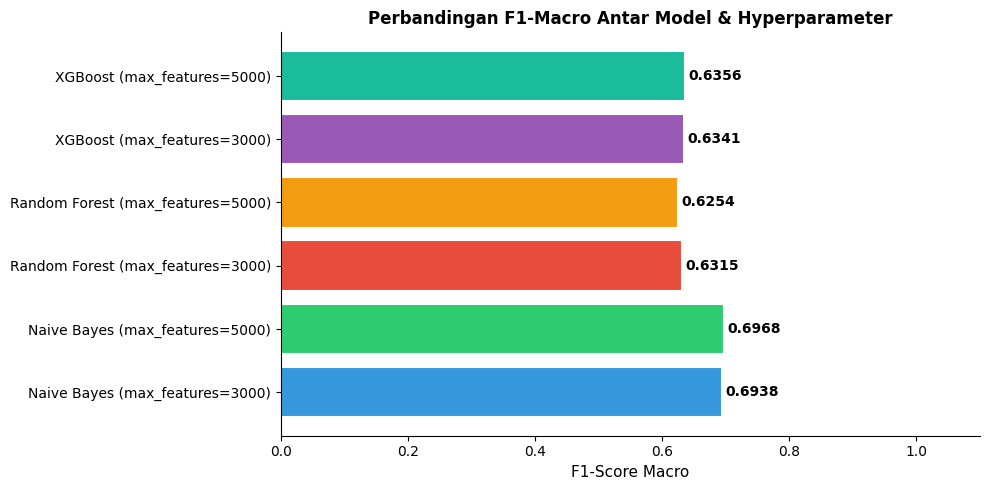


Classification Report — Naive Bayes (max_features=5000):
              precision    recall  f1-score   support

     Negatif       0.63      0.68      0.65       140
      Netral       0.57      0.62      0.59       140
     Positif       0.93      0.77      0.84       140

    accuracy                           0.69       420
   macro avg       0.71      0.69      0.70       420
weighted avg       0.71      0.69      0.70       420



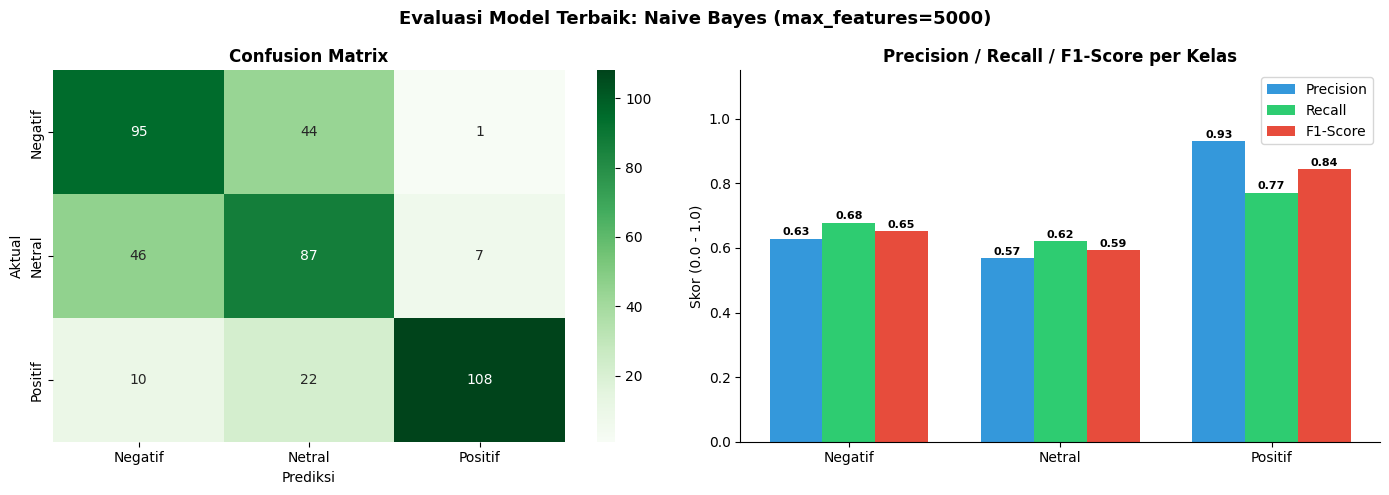


Grafik evaluasi model terbaik tersimpan: /content/evaluasi_model_terbaik.png


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_recall_fscore_support)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# ============================================================
# TAHAP 1.7 — Perbandingan Model & Hyperparameter
# Membandingkan Naive Bayes, Random Forest, dan XGBoost
# dengan variasi max_features TF-IDF: 3000 dan 5000
# ============================================================

# Split Data
X = df_sample['review_clean']
y = df_sample[SENTIMEN_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Ukuran Data Training : {len(X_train):,} ulasan")
print(f"Ukuran Data Testing  : {len(X_test):,} ulasan")

# Encode label untuk XGBoost (butuh angka, bukan teks)
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
y_enc       = le.transform(y)  # untuk CV XGBoost

# Definisikan kombinasi eksperimen
eksperimen = [
    {
        'nama'         : 'Naive Bayes (max_features=3000)',
        'max_features' : 3000,
        'model'        : MultinomialNB(alpha=0.1),
        'encode_label' : False
    },
    {
        'nama'         : 'Naive Bayes (max_features=5000)',
        'max_features' : 5000,
        'model'        : MultinomialNB(alpha=0.1),
        'encode_label' : False
    },
    {
        'nama'         : 'Random Forest (max_features=3000)',
        'max_features' : 3000,
        'model'        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'encode_label' : False
    },
    {
        'nama'         : 'Random Forest (max_features=5000)',
        'max_features' : 5000,
        'model'        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'encode_label' : False
    },
    {
        'nama'         : 'XGBoost (max_features=3000)',
        'max_features' : 3000,
        'model'        : XGBClassifier(n_estimators=100, random_state=42,
                                       eval_metric='mlogloss',
                                       n_jobs=-1),
        'encode_label' : True
    },
    {
        'nama'         : 'XGBoost (max_features=5000)',
        'max_features' : 5000,
        'model'        : XGBClassifier(n_estimators=100, random_state=42,
                                       eval_metric='mlogloss',
                                       n_jobs=-1),
        'encode_label' : True
    },
]

# Tampung hasil semua eksperimen
hasil_semua = []

for exp in eksperimen:
    print(f"\nMelatih: {exp['nama']}...")
    waktu_mulai = time.time()

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features = exp['max_features'],
            ngram_range  = (1, 2),
            min_df       = 2,
            max_df       = 0.95,
            sublinear_tf = True
        )),
        ('clf', exp['model'])
    ])

    # Gunakan label encoded hanya untuk XGBoost
    y_tr = y_train_enc if exp['encode_label'] else y_train

    pipeline.fit(X_train, y_tr)
    y_pred_raw = pipeline.predict(X_test)

    waktu_selesai = time.time()

    # Decode balik label XGBoost agar bisa dibandingkan dengan y_test asli
    y_pred = le.inverse_transform(y_pred_raw) if exp['encode_label'] else y_pred_raw

    # Semua metrik pakai y_test asli agar konsisten
    akurasi   = accuracy_score(y_test, y_pred)
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_weight = f1_score(y_test, y_pred, average='weighted')

    # Cross Validation
    y_cv    = y_enc if exp['encode_label'] else y
    skor_cv = cross_val_score(pipeline, X, y_cv, cv=5, scoring='accuracy', n_jobs=-1)

    hasil_semua.append({
        'Model'         : exp['nama'],
        'Accuracy'      : round(akurasi * 100, 2),
        'F1-Macro'      : round(f1_macro, 4),
        'F1-Weighted'   : round(f1_weight, 4),
        'CV Mean'       : round(skor_cv.mean() * 100, 2),
        'CV Std'        : round(skor_cv.std() * 100, 2),
        'Waktu (detik)' : round(waktu_selesai - waktu_mulai, 2),
        'pipeline'      : pipeline,
        'y_pred'        : y_pred,
    })

    print(f"Selesai dalam {waktu_selesai - waktu_mulai:.2f} detik")
    print(f"Accuracy  : {akurasi*100:.2f}% | F1-Macro : {f1_macro:.4f} | F1-Weighted : {f1_weight:.4f}")
    print(f"CV Mean   : {skor_cv.mean()*100:.2f}% ± {skor_cv.std()*100:.2f}%")


# ============================================================
# Tabel Perbandingan Hasil
# ============================================================
print("\n" + "="*75)
print("TABEL PERBANDINGAN SEMUA MODEL & HYPERPARAMETER")
print("="*75)
df_hasil = pd.DataFrame(hasil_semua)[['Model', 'Accuracy', 'F1-Macro', 'F1-Weighted', 'CV Mean', 'CV Std', 'Waktu (detik)']]
print(df_hasil.to_string(index=False))
print("="*75)

# Tentukan model terbaik berdasarkan F1-Macro
idx_terbaik   = df_hasil['F1-Macro'].idxmax()
model_terbaik = hasil_semua[idx_terbaik]
print(f"\nModel Terbaik : {model_terbaik['Model']}")
print(f"F1-Macro      : {model_terbaik['F1-Macro']}")
print(f"CV Mean       : {model_terbaik['CV Mean']}% ± {model_terbaik['CV Std']}%")


# ============================================================
# Visualisasi Perbandingan F1-Macro semua model
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
warna = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
bars  = ax.barh(
    df_hasil['Model'],
    df_hasil['F1-Macro'],
    color=warna[:len(df_hasil)],
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, df_hasil['F1-Macro']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, 1.1)
ax.set_xlabel('F1-Score Macro', fontsize=11)
ax.set_title('Perbandingan F1-Macro Antar Model & Hyperparameter',
             fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# Classification Report & Confusion Matrix Model Terbaik
# ============================================================
print(f"\nClassification Report — {model_terbaik['Model']}:")
target_labels = sorted(df_sample[SENTIMEN_COL].unique())
print(classification_report(y_test, model_terbaik['y_pred'], target_names=target_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Evaluasi Model Terbaik: {model_terbaik['Model']}",
             fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, model_terbaik['y_pred'], labels=target_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_labels,
            yticklabels=target_labels,
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Precision / Recall / F1 per Kelas
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, model_terbaik['y_pred'], labels=target_labels
)
x_pos = np.arange(len(target_labels))
width = 0.25
axes[1].bar(x_pos - width, precision, width, label='Precision', color='#3498db')
axes[1].bar(x_pos,         recall,    width, label='Recall',    color='#2ecc71')
axes[1].bar(x_pos + width, f1,        width, label='F1-Score',  color='#e74c3c')
for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    axes[1].text(i - width, p + 0.01, f'{p:.2f}', ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i,         r + 0.01, f'{r:.2f}', ha='center', fontsize=8, fontweight='bold')
    axes[1].text(i + width, f + 0.01, f'{f:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(target_labels)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Precision / Recall / F1-Score per Kelas', fontweight='bold')
axes[1].set_ylabel('Skor (0.0 - 1.0)')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/evaluasi_model_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGrafik evaluasi model terbaik tersimpan: /content/evaluasi_model_terbaik.png")

sekarang akurasinya sekitar 69%, memang turun dari data yang digunakan sebelumnya. tapi ini lebih bisa belajar model dalam menentukan sentimen.

### Evaluasi Model Terbaik: Naive Bayes (max_features=5000)

Setelah membandingkan 6 kombinasi model dan hyperparameter (Naive Bayes,
Random Forest, dan XGBoost masing-masing dengan max_features 3000 dan 5000),
model **Multinomial Naive Bayes dengan max_features=5000** terpilih sebagai
model terbaik berdasarkan F1-Macro tertinggi.

**CONFUSION MATRIX**

Model berhasil mengenali ketiga kelas sentimen, yang sebelumnya gagal total untuk kelas Negatif dan Netral. Diagonal utama (kiri atas ke kanan bawah) menunjukkan prediksi benar — Negatif: 95, Netral: 87, Positif: 108. Kesalahan terbesar terjadi pada kebingungan antara kelas Negatif dan Netral (44 data Negatif salah ditebak sebagai Netral, dan 46 data Netral salah ditebak sebagai Negatif). Ini wajar secara linguistik karena ulasan bintang 1-2 dan bintang 3 seringkali menggunakan diksi yang mirip seperti "kurang memuaskan" atau "biasa saja".

**Precision / Recall / F1-Score per Kelas**

- Positif adalah kelas terkuat dengan Precision 0.93 yang artinya ketika model menebak sebuah ulasan itu Positif, 93% kemungkinannya memang benar Positif. F1-Score-nya 0.84 menunjukkan performa yang solid.
- Negatif berada di tengah dengan F1-Score 0.65, model cukup andal mendeteksi komplain pelanggan meskipun masih ada kebocoran ke kelas Netral.
- Netral adalah kelas terlemah dengan F1-Score 0.59 krn paling sulit dibedakan karena secara bahasa ulasan netral memang paling ambigu, tidak jelas positif maupun negatif.

Model terbaik hasil seleksi (Naive Bayes max_features=5000) sudah berfungsi
secara nyata dan adil untuk ketiga kelas dengan F1-Macro 0.70 — jauh lebih
baik dibandingkan kondisi sebelum balanced sampling yang hanya mampu
mendeteksi kelas Positif saja (F1-Macro 0.35). Model ini yang akan
diserialisasi dan digunakan pada dashboard Streamlit di tahap berikutnya.

### Serialisasi Objek Model

In [ ]:
import pickle
import textwrap
# ============================================================
# TAHAP 1.8 — Serialisasi Model (Menyimpan Pipeline ke File .pkl)
# ============================================================
# Serialisasi = mengubah objek Python (pipeline model) menjadi
# representasi biner yang dapat disimpan ke disk dan dimuat
# kembali tanpa perlu melatih ulang dari awal.
# Pipeline yang disimpan mencakup TF-IDF Vectorizer + Multinomial Naive Bayes
# sekaligus dalam satu file, sehingga saat deploy tidak perlu fit ulang.
# ============================================================

PATH_MODEL = '/content/model_tokopedia.pkl'

with open(PATH_MODEL, 'wb') as file:
    pickle.dump(model_terbaik['pipeline'], file)

model_size_kb = os.path.getsize(PATH_MODEL) / 1024
model_size_mb = model_size_kb / 1024

print("="*50)
print("MODEL BERHASIL DISERIALISASI")
print("="*50)
print(f" File      : {PATH_MODEL}")
print(f" Ukuran    : {model_size_kb:.2f} KB ({model_size_mb:.2f} MB)")
print("="*50)


# ============================================================
# Uji Coba (Sanity Check) — memuat kembali file .pkl
# dan memastikan prediksinya konsisten menggunakan
# sampel acak dari data testing yang sudah ada
# ============================================================
print("\nVerifikasi model hasil serialisasi...")
with open(PATH_MODEL, 'rb') as file:
    loaded_model = pickle.load(file)

# Ambil 1 sampel acak per kelas agar semua sentimen terwakili
sampel_list = []
for kelas in sorted(df_sample[SENTIMEN_COL].unique()):
    idx_kelas = y_test[y_test == kelas].index
    sampel_idx = idx_kelas.to_series().sample(1, random_state=42).index[0]
    sampel_list.append({
        'teks_bersih' : X_test[sampel_idx],
        'teks_asli'   : df_sample.loc[sampel_idx, TEXT_COL] if TEXT_COL in df_sample.columns else X_test[sampel_idx],
        'label_asli'  : y_test[sampel_idx]
    })

classes = loaded_model.classes_

print("\nTest Prediksi Model (1 Sampel Acak per Kelas Sentimen):")
print("-" * 65)
for item in sampel_list:
    prediksi     = loaded_model.predict([item['teks_bersih']])[0]
    probabilitas = loaded_model.predict_proba([item['teks_bersih']])[0]
    confidence   = max(probabilitas) * 100
    prob_str     = ' | '.join([f"{c}: {p*100:.1f}%" for c, p in zip(classes, probabilitas)])
    status       = "✅ BENAR" if prediksi == item['label_asli'] else "❌ SALAH"

    # print(f"Ulasan Asli : {str(item['teks_asli'])[:60]}...")
    # Tampilkan penuh tapi dibungkus rapi setiap 65 karakter
    ulasan_wrapped = textwrap.fill(str(item['teks_asli']), width=65)
    print(f"Ulasan Asli :\n{ulasan_wrapped}")
    print(f"Label Asli  : {item['label_asli']}")
    print(f"Prediksi    : {prediksi} (Confidence: {confidence:.1f}%) {status}")
    print(f"Probabilitas: [{prob_str}]")
    print("-" * 65)

print("\nVerifikasi berhasil. Model siap untuk deployment.")

MODEL BERHASIL DISERIALISASI
 File      : /content/model_tokopedia.pkl
 Ukuran    : 392.64 KB (0.38 MB)

Verifikasi model hasil serialisasi...

Test Prediksi Model (1 Sampel Acak per Kelas Sentimen):
-----------------------------------------------------------------
Ulasan Asli :
kartu telkomsel simpati isi Telkomsel lite, dikasih kartu wilayah
PAMASUKA pdhl jabodetabek, jaringan kosong bgni gimana mau bisa
kirim sms registrasi? PENJUAL SLOW RESPON, MESTI DATANGIN CS
TELKOMSEL. BIKIN REPOT
Label Asli  : Negatif
Prediksi    : Negatif (Confidence: 90.6%) ✅ BENAR
Probabilitas: [Negatif: 90.6% | Netral: 9.0% | Positif: 0.5%]
-----------------------------------------------------------------
Ulasan Asli :
Admin yg respon chat jutek. Pengirimannya lama, estimasi paket
tiba tgl 18-20 tapi paketnya baru sampai tgl 21. Packingnya cuma
pke amplop doang (gak dibungkus plastik lagi, untung ga basah
kena hujan), kondisi amplop kotor dan lusuh pas diterima.
Barangnya baru, masih di segel. Dapet nomer 

cell diatas: Hasil verifikasi menunjukkan 2 dari 3 sampel acak berhasil diprediksi dengan benar. Satu kesalahan terjadi pada kelas Netral yang
diprediksi sebagai Negatif hal ini dapat dimaklumi karena konten
ulasan tersebut secara linguistik memang bernada negatif (komplain
respon admin dan keterlambatan pengiriman), namun pembeli memberikan
rating bintang 3 (Netral). Kasus ini mencerminkan tantangan umum
dalam analisis sentimen berbasis rating: label tidak selalu
mencerminkan isi teks secara konsisten

---
# TAHAP 2: Pengembangan Dashboard Streamlit

Pada tahap ini kita akan membuat skrip `app.py` menggunakan **magic command `%%writefile`** di Colab. Skrip ini adalah aplikasi web interaktif yang memuat model terlatih dan menyediakan antarmuka prediksi sentimen bagi pengguna.

**Fitur Dashboard:**
| Fitur | Deskripsi |
|---|---|
| Judul Aplikasi | "Analisis Sentimen Ulasan Tokopedia" |
| Input Teks | Kotak teks untuk memasukkan ulasan |
| Tombol Prediksi | Trigger inferensi model |
| Hasil Prediksi | Label sentimen + confidence + gauge chart |
| Visualisasi Probabilitas | Bar chart probabilitas per kelas |
| Info Model | Akurasi, statistik model |

> **Catatan:** Magic command `%%writefile app.py` menulis seluruh isi cell ke file `app.py` di filesystem Colab — tidak ada baris kode yang dieksekusi langsung.

### Generate app.py Otomatis
menggunakan command %%writefile untuk membuat berkas aplikasi web mandiri langsung dari ekosistem notebook Google Colab.

In [ ]:
%%writefile /content/app.py
# ============================================================
# app.py — Dashboard Streamlit: Analisis Sentimen Tokopedia
# PROJECT INTERNSHIP VINIX7 — Deployment
# ============================================================

import streamlit as st
import pickle
import re
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Konfigurasi Halaman
st.set_page_config(
    page_title="Analisis Sentimen Tokopedia",
    page_icon="🛒",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# Custom CSS — Redesign Lengkap
# ============================================================
st.markdown("""
<style>
    /* ── Background Halaman ── */
    [data-testid="stAppViewContainer"] {
        background: linear-gradient(135deg, #eef2ff 0%, #f0fdf4 50%, #fef9ee 100%);
    }
    [data-testid="stMain"] {
        background: transparent;
    }

    /* ── Sidebar ── */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #1e2a4a 0%, #2d3f6e 100%);
        border-right: none;
    }
    [data-testid="stSidebar"] * {
        color: #e2e8f0 !important;
    }
    [data-testid="stSidebar"] .stMarkdown strong {
        color: #a5b4fc !important;
    }
    [data-testid="stSidebar"] .stAlert {
        background: rgba(99,102,241,0.15) !important;
        border: 0.5px solid rgba(165,180,252,0.3) !important;
        border-radius: 10px !important;
    }
    [data-testid="stSidebar"] code {
        background: rgba(255,255,255,0.08) !important;
        color: #a5b4fc !important;
        border-radius: 6px !important;
    }
    [data-testid="stSidebar"] .stSuccess {
        background: rgba(34,197,94,0.15) !important;
        border: 0.5px solid rgba(34,197,94,0.35) !important;
        border-radius: 10px !important;
    }
    [data-testid="stSidebar"] .stError {
        background: rgba(239,68,68,0.15) !important;
        border: 0.5px solid rgba(239,68,68,0.35) !important;
        border-radius: 10px !important;
    }

    /* ── Header ── */
    .main-title {
        font-size: 2.3rem;
        font-weight: 800;
        background: linear-gradient(135deg, #4f46e5, #0ea5e9);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        background-clip: text;
        text-align: center;
        letter-spacing: -0.03em;
        line-height: 1.2;
        padding: 0.25rem 0;
    }
    .subtitle {
        font-size: 0.9rem;
        color: #64748b;
        text-align: center;
        margin-bottom: 0.5rem;
        font-weight: 400;
    }
    .header-badge {
        display: flex;
        justify-content: center;
        gap: 8px;
        margin-bottom: 1.5rem;
    }
    .badge-item {
        display: inline-block;
        padding: 3px 12px;
        border-radius: 999px;
        font-size: 0.72rem;
        font-weight: 600;
        letter-spacing: 0.05em;
    }
    .badge-blue  { background: #dbeafe; color: #1d4ed8; }
    .badge-green { background: #dcfce7; color: #15803d; }
    .badge-purple{ background: #ede9fe; color: #6d28d9; }

    /* ── Section Label ── */
    .section-label {
        font-size: 0.72rem;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.1em;
        color: #94a3b8;
        margin-bottom: 0.5rem;
    }

    /* ── Panel Kolom ── */
    .panel {
        background: rgba(255,255,255,0.85);
        border: 0.5px solid rgba(99,102,241,0.15);
        border-radius: 16px;
        padding: 1.5rem;
        backdrop-filter: blur(8px);
    }

    /* ── Text Area ── */
    textarea {
        border-radius: 10px !important;
        border: 1.5px solid #e0e7ff !important;
        background: #f8faff !important;
        font-size: 0.88rem !important;
        line-height: 1.75 !important;
        color: #1e2a4a !important;
        transition: all 0.2s ease !important;
    }
    textarea:focus {
        border-color: #6366f1 !important;
        background: #ffffff !important;
        box-shadow: 0 0 0 4px rgba(99,102,241,0.1) !important;
    }

    /* ── Tombol Contoh ── */
    div[data-testid="stHorizontalBlock"] button {
        border-radius: 10px !important;
        font-size: 13px !important;
        font-weight: 600 !important;
        transition: all 0.18s ease !important;
        padding: 0.45rem 0 !important;
    }

    /* ── Tombol Analisis (primary) ── */
    button[kind="primary"] {
        background: linear-gradient(135deg, #4f46e5, #0ea5e9) !important;
        border: none !important;
        border-radius: 10px !important;
        font-weight: 600 !important;
        font-size: 0.95rem !important;
        letter-spacing: 0.02em !important;
        box-shadow: 0 4px 14px rgba(79,70,229,0.35) !important;
        padding: 0.65rem 0 !important;
        transition: all 0.2s ease !important;
    }
    button[kind="primary"]:hover {
        box-shadow: 0 6px 20px rgba(79,70,229,0.45) !important;
        transform: translateY(-1px) !important;
    }

    /* ── Metric Streamlit ── */
    [data-testid="stMetric"] {
        background: linear-gradient(135deg, #eef2ff, #e0e7ff);
        border-radius: 12px;
        padding: 0.75rem 1rem;
        border: 0.5px solid #c7d2fe;
    }
    [data-testid="stMetricLabel"] {
        font-size: 0.72rem !important;
        font-weight: 600 !important;
        text-transform: uppercase !important;
        letter-spacing: 0.06em !important;
        color: #6366f1 !important;
    }
    [data-testid="stMetricValue"] {
        font-size: 1.3rem !important;
        font-weight: 700 !important;
        color: #1e2a4a !important;
    }

    /* ── Result Box ── */
    .result-box {
        border-radius: 14px;
        padding: 1.1rem 1.4rem;
        margin: 0.5rem 0 1rem;
        display: flex;
        align-items: center;
        gap: 14px;
    }
    .result-icon {
        font-size: 2rem;
        line-height: 1;
        flex-shrink: 0;
    }
    .result-tag {
        font-size: 0.68rem;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 0.09em;
        opacity: 0.65;
        margin-bottom: 3px;
    }
    .result-sentiment {
        font-size: 1.45rem;
        font-weight: 800;
        letter-spacing: -0.02em;
        line-height: 1.15;
    }
    .result-conf {
        font-size: 0.8rem;
        margin-top: 3px;
        opacity: 0.7;
    }
    .positif {
        background: linear-gradient(135deg, #f0fdf4, #dcfce7);
        color: #14532d;
        border: 1px solid #86efac;
        border-left: 5px solid #16a34a;
    }
    .negatif {
        background: linear-gradient(135deg, #fef2f2, #fee2e2);
        color: #7f1d1d;
        border: 1px solid #fca5a5;
        border-left: 5px solid #dc2626;
    }
    .netral {
        background: linear-gradient(135deg, #fffbeb, #fef3c7);
        color: #78350f;
        border: 1px solid #fcd34d;
        border-left: 5px solid #d97706;
    }

    /* ── Alert / Success / Warning / Error ── */
    [data-testid="stAlert"] {
        border-radius: 10px !important;
        font-size: 0.85rem !important;
    }

    /* ── Expander ── */
    [data-testid="stExpander"] {
        border: 0.5px solid #e0e7ff !important;
        border-radius: 10px !important;
        background: #fafbff !important;
    }
    [data-testid="stExpander"] summary {
        font-weight: 600 !important;
        color: #4f46e5 !important;
        font-size: 0.85rem !important;
    }

    /* ── Divider ── */
    hr {
        border: none !important;
        border-top: 1px solid rgba(99,102,241,0.12) !important;
        margin: 1.25rem 0 !important;
    }

    /* ── Footer ── */
    .footer-custom {
        text-align: center;
        color: #94a3b8;
        font-size: 0.78rem;
        padding: 0.5rem 0 1rem;
        letter-spacing: 0.02em;
    }
    .footer-custom span {
        color: #a5b4fc;
        font-weight: 600;
    }
</style>
""", unsafe_allow_html=True)


# ============================================================
# Fungsi Utilitas
# ============================================================

@st.cache_resource
def load_model(model_path='model_tokopedia.pkl'):
    if not os.path.exists(model_path):
        return None
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model


def clean_text_pro(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([word for word in text.split() if len(word) >= 2])
    return text


def predict_sentimen(model, text):
    cleaned    = clean_text_pro(text)
    label      = model.predict([cleaned])[0]
    proba      = model.predict_proba([cleaned])[0]
    classes    = model.classes_
    confidence = max(proba) * 100
    return label, confidence, dict(zip(classes, proba * 100))


def plot_probabilitas(proba_dict):
    # Warna gradient per label
    color_main = {'Positif': '#16a34a', 'Netral': '#d97706', 'Negatif': '#dc2626'}
    color_bg   = {'Positif': '#dcfce7', 'Netral': '#fef3c7', 'Negatif': '#fee2e2'}

    labels = list(proba_dict.keys())
    values = list(proba_dict.values())

    fig, ax = plt.subplots(figsize=(5.5, 2.6))
    fig.patch.set_facecolor('none')   # transparan agar menyatu dengan bg Streamlit
    ax.set_facecolor('#f8faff')

    # Bar background (track)
    for i, lbl in enumerate(labels):
        ax.barh(i, 100, color=color_bg.get(lbl, '#f1f5f9'), height=0.55,
                zorder=1, left=0)

    # Bar value
    bars = ax.barh(
        range(len(labels)), values,
        color=[color_main.get(l, '#6366f1') for l in labels],
        height=0.55, zorder=2, left=0,
        linewidth=0
    )

    # Label angka di dalam/luar bar
    for i, (bar, val) in enumerate(zip(bars, values)):
        x_pos = val - 2 if val > 15 else val + 1.5
        ha    = 'right' if val > 15 else 'left'
        txt_color = 'white' if val > 15 else color_main.get(labels[i], '#334155')
        ax.text(x_pos, i, f'{val:.1f}%',
                va='center', ha=ha,
                fontweight='700', fontsize=10.5,
                color=txt_color, zorder=3)

    # Label sumbu Y (nama kelas)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=11, fontweight='600', color='#1e2a4a')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Probabilitas (%)', fontsize=9, color='#94a3b8', labelpad=6)

    # Bersihkan spines
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='x', colors='#94a3b8', labelsize=8.5)
    ax.tick_params(axis='y', left=False)

    # Grid vertikal tipis
    ax.xaxis.grid(True, color='#e0e7ff', linewidth=0.6, linestyle='--', zorder=0)
    ax.set_axisbelow(True)

    plt.tight_layout(pad=0.6)
    return fig


# ============================================================
# Inisialisasi Session State
# ============================================================
if 'contoh_ulasan' not in st.session_state:
    st.session_state['contoh_ulasan'] = ''
if 'hasil_label' not in st.session_state:
    st.session_state['hasil_label'] = None
if 'hasil_confidence' not in st.session_state:
    st.session_state['hasil_confidence'] = None
if 'hasil_proba' not in st.session_state:
    st.session_state['hasil_proba'] = None
if 'teks_analisis' not in st.session_state:
    st.session_state['teks_analisis'] = ''

# ============================================================
# MAIN APPLICATION
# ============================================================

# Header
st.markdown('<p class="main-title">Analisis Sentimen Ulasan Tokopedia</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Dashboard prediksi sentimen ulasan pelanggan berbasis Machine Learning</p>', unsafe_allow_html=True)
st.markdown("""
<div class="header-badge">
    <span class="badge-item badge-purple">Multinomial Naive Bayes</span>
    <span class="badge-item badge-blue">TF-IDF · n-gram (1,2)</span>
    <span class="badge-item badge-green">Bahasa Indonesia</span>
</div>
""", unsafe_allow_html=True)
st.markdown('---')

# Load Model
model = load_model('model_tokopedia.pkl')
if model is None:
    st.error('File model tidak ditemukan. Pastikan `model_tokopedia.pkl` ada di direktori yang sama dengan `app.py`.')
    st.stop()

# ============================================================
# Info Model Terbaik — sesuaikan jika model terbaik berubah
# ============================================================
MODEL_ALGORITHM = "Multinomial NB"
MODEL_FEATURES  = "5,000"

# Sidebar
with st.sidebar:
    st.image('https://lf-web-assets.tokopedia-static.net/obj/tokopedia-web-sg/arael_v3/9438c3e2.png',
             width=160)
    st.markdown('---')
    st.markdown('**TENTANG APLIKASI**')
    st.info(
        'Aplikasi ini menggunakan model **Multinomial Naive Bayes** '
        'dengan **TF-IDF Vectorizer** untuk mengklasifikasikan '
        'ulasan produk ke dalam 3 kategori sentimen.'
    )
    st.markdown('---')
    st.markdown('**LABEL SENTIMEN**')
    st.markdown('🟢 **Positif** — Rating 4–5 ⭐')
    st.markdown('🟡 **Netral** — Rating 3 ⭐')
    st.markdown('🔴 **Negatif** — Rating 1–2 ⭐')
    st.markdown('---')
    st.markdown('**MODEL INFO**')
    st.markdown("""
      <div style="
        background: rgba(255,255,255,0.07);
        border: 0.5px solid rgba(165,180,252,0.25);
        border-radius: 10px;
        padding: 0.85rem 1rem;
        font-family: 'Courier New', monospace;
        font-size: 0.78rem;
        line-height: 1.9;
        color: #a5b4fc;
      ">
        <span style="color:#7dd3fc;">Algorithm </span> : """ + MODEL_ALGORITHM + """<br>
        <span style="color:#7dd3fc;">Vectorizer</span> : TF-IDF (n-gram 1,2)<br>
        <span style="color:#7dd3fc;">Features  </span> : """ + MODEL_FEATURES + """<br>
        <span style="color:#7dd3fc;">Language  </span> : Bahasa Indonesia
      </div>
    """, unsafe_allow_html=True)
    st.markdown('---')
    st.markdown('**Status Model**')
    if os.path.exists('model_tokopedia.pkl'):
        size_mb = os.path.getsize('model_tokopedia.pkl') / (1024 * 1024)
        st.success(f'✅ Model dimuat ({size_mb:.2f} MB)')
    else:
        st.error('❌ model_tokopedia.pkl tidak ditemukan')

# ============================================================
# Layout Utama
# ============================================================
col_input, col_result = st.columns([1.2, 1], gap="large")

with col_input:
    st.markdown('<div class="section-label">✏️ Masukkan Ulasan Produk</div>', unsafe_allow_html=True)
    user_review = st.text_area(
        label='Tulis ulasan di sini:',
        placeholder='Contoh: "Produk bagus, pengiriman cepat, kemasan aman. Sangat puas dengan pembelian ini!"',
        height=180,
        value=st.session_state['contoh_ulasan'],
        key='review_input'
    )

    st.markdown('<div class="section-label">⚡ Atau pilih contoh ulasan</div>', unsafe_allow_html=True)
    col_ex1, col_ex2, col_ex3 = st.columns(3)
    ex_pos = col_ex1.button('✅ Positif',  use_container_width=True)
    ex_net = col_ex2.button('⚠️ Netral',   use_container_width=True)
    ex_neg = col_ex3.button('❌ Negatif',  use_container_width=True)

    if ex_pos:
        st.session_state['contoh_ulasan'] = 'wanginya suka, sesuai deskripsi, packing aman dan pengiriman cepat'
        st.session_state['teks_analisis'] = st.session_state['contoh_ulasan']
        st.session_state['hasil_label'], st.session_state['hasil_confidence'], st.session_state['hasil_proba'] = \
            predict_sentimen(model, st.session_state['contoh_ulasan'])
    elif ex_net:
        st.session_state['contoh_ulasan'] = 'saya puas dengan bahan nya yg bgs...tp sayang ada yg putus benang nya'
        st.session_state['teks_analisis'] = st.session_state['contoh_ulasan']
        st.session_state['hasil_label'], st.session_state['hasil_confidence'], st.session_state['hasil_proba'] = \
            predict_sentimen(model, st.session_state['contoh_ulasan'])
    elif ex_neg:
        st.session_state['contoh_ulasan'] = 'Sangat mengecewakan. Stock tidak update, orderan saya dicancel berkali2 karena barang habis. Sekalinya dikirim barang sudah meleleh cair semua karena packing tidak proper. Pilihan styrofoam tdk tersedia di cabang pengiriman. Not recommended'
        st.session_state['teks_analisis'] = st.session_state['contoh_ulasan']
        st.session_state['hasil_label'], st.session_state['hasil_confidence'], st.session_state['hasil_proba'] = \
            predict_sentimen(model, st.session_state['contoh_ulasan'])

    if user_review:
        word_count = len(user_review.split())
        char_count = len(user_review)
        c1, c2 = st.columns(2)
        c1.metric('Jumlah Kata', f'{word_count} kata')
        c2.metric('Jumlah Karakter', f'{char_count} karakter')

    predict_btn = st.button('🔍 Analisis Sentimen', type='primary', use_container_width=True)

    if predict_btn and user_review.strip():
        with st.spinner('Menganalisis ulasan...'):
            time.sleep(0.5)
            st.session_state['teks_analisis'] = user_review
            st.session_state['hasil_label'], st.session_state['hasil_confidence'], st.session_state['hasil_proba'] = \
                predict_sentimen(model, user_review)
    elif predict_btn and not user_review.strip():
        st.warning('⚠️ Harap masukkan teks ulasan terlebih dahulu.')


with col_result:
    st.markdown('<div class="section-label">📊 Hasil Prediksi</div>', unsafe_allow_html=True)
    if st.session_state['hasil_label'] is not None:
        label      = st.session_state['hasil_label']
        confidence = st.session_state['hasil_confidence']
        proba_dict = st.session_state['hasil_proba']
        emoji_map = {'Positif': '✅', 'Netral': '⚠️', 'Negatif': '❌'}
        css_class = label.lower()
        emoji     = emoji_map.get(label, '🔵')
        st.markdown(
            f'<div class="result-box {css_class}">'
            f'  <div class="result-icon">{emoji}</div>'
            f'  <div>'
            f'    <div class="result-tag">Sentimen Terdeteksi</div>'
            f'    <div class="result-sentiment">{label}</div>'
            f'    <div class="result-conf">Confidence: <strong>{confidence:.1f}%</strong></div>'
            f'  </div>'
            f'</div>',
            unsafe_allow_html=True
        )

        # ✅ TAMBAHKAN DI SINI — setelah result-box, sebelum chart
        if st.session_state.get('teks_analisis'):
            st.markdown(
                f"""
                <div style="
                    background: rgba(99,102,241,0.05);
                    border: 1px solid #e0e7ff;
                    border-left: 4px solid #6366f1;
                    border-radius: 10px;
                    padding: 0.7rem 1rem;
                    font-size: 0.84rem;
                    color: #334155;
                    line-height: 1.7;
                    margin: 0.75rem 0 1rem;
                    font-style: italic;
                ">
                    <span style="font-style:normal; font-size:0.7rem; font-weight:700;
                                 text-transform:uppercase; letter-spacing:0.08em; color:#94a3b8;
                                 display:block; margin-bottom:4px;">📝 Ulasan yang Dianalisis</span>
                    "{st.session_state['teks_analisis']}"
                </div>
                """,
                unsafe_allow_html=True
            )

        fig = plot_probabilitas(proba_dict)
        st.pyplot(fig, use_container_width=True)
        if label == 'Positif':
            st.success('🎉 Ulasan ini mencerminkan kepuasan pelanggan yang tinggi. Pertahankan kualitas produk dan layanan!')
        elif label == 'Negatif':
            st.error('🚨 Ulasan ini menunjukkan ketidakpuasan. Perlu tindak lanjut dari tim customer service.')
        else:
            st.warning('💡 Ulasan ini bersifat netral. Ada peluang untuk meningkatkan kepuasan pelanggan.')
        with st.expander('🔎 Detail Probabilitas per Kelas'):
            for cls, prob in sorted(proba_dict.items(), key=lambda x: x[1], reverse=True):
                st.progress(int(prob), text=f'{cls}: {prob:.2f}%')
    else:
        st.markdown("""
        <div style="
            text-align:center;
            padding: 3rem 1.5rem;
            background: rgba(99,102,241,0.04);
            border: 1.5px dashed #c7d2fe;
            border-radius: 14px;
            color: #94a3b8;
        ">
            <div style="font-size:2.5rem; margin-bottom:0.75rem;">📝</div>
            <div style="font-size:0.88rem; font-weight:500; color:#64748b;">
                Masukkan ulasan dan klik<br>
                <strong style="color:#6366f1;">Analisis Sentimen</strong>
                untuk memulai prediksi.
            </div>
        </div>
        """, unsafe_allow_html=True)


# Footer
st.markdown('---')
st.markdown(
    '<div class="footer-custom">'
    'Project: <span>Deployment &amp; MLOps</span> · '
    'Dataset: <span>Tokopedia Product Reviews 2025</span> (Kaggle)'
    ' · Developed: <span>Athifahnr</span>'
    '</div>',
    unsafe_allow_html=True
)

Overwriting /content/app.py


In [ ]:
# Cari contoh ulasan terbaik per kelas untuk hardcode di app.py
for kelas in ['Positif', 'Netral', 'Negatif']:
    idx_benar = y_test[y_test == kelas].index
    for idx in idx_benar:
        teks_asli = df_sample.loc[idx, TEXT_COL]
        prediksi  = model_terbaik['pipeline'].predict([X_test[idx]])[0]
        prob      = model_terbaik['pipeline'].predict_proba([X_test[idx]]).max()
        # Filter: prediksi benar, confidence tinggi, panjang teks cukup
        if prediksi == kelas and prob > 0.80 and len(teks_asli.split()) > 8:
            print(f"[{kelas}] Confidence: {prob*100:.1f}%")
            print(f"Teks: {teks_asli}")
            print("-"*60)
            break

[Positif] Confidence: 99.1%
Teks: wanginya suka, sesuai deskripsi, packing aman dan pengiriman cepat..
------------------------------------------------------------
[Netral] Confidence: 85.8%
Teks: saya puas dengan bahan nya yg bgs...tp sayang ada yg putus benang nya
------------------------------------------------------------
[Negatif] Confidence: 98.5%
Teks: Sangat mengecewakan. Stock tidak update, orderan saya dicancel berkali2 karena barang habis. Sekalinya dikirim barang sudah meleleh cair semua karena packing tidak proper. Pilihan styrofoam tdk tersedia di cabang pengiriman. Not recommended.
------------------------------------------------------------


# TAHAP 3: Deployment & Tunneling

Pada tahap ini kita menjalankan aplikasi Streamlit di background Colab dan mengeksposnya ke internet menggunakan **NGROK** — solusi tunneling yang gratis, stabil, dan memerlukan token autentikasi.
**Alur Deployment:**
```
[Google Colab] ──► [Streamlit :8501] ──► [NGROK] ──► [URL Publik]
  (server)          (local port)      (secure tunnel)   (dapat diakses siapa saja)
```

> **Catatan Teknis:** NGROK membuat koneksi keluar (*outbound*) dari server Colab ke jaringan publik agar bisa diakses dari manapun dibrowser.

In [ ]:
!pip install pyngrok -q
print("pyngrok berhasil diinstall!")

pyngrok berhasil diinstall!


In [ ]:
import subprocess
import time
import urllib.request
from pyngrok import ngrok, conf

# ============================================================
# TAHAP 3 — Deployment & Tunneling (NGROK — Dengan Token)
# ============================================================
# Alur Deployment:
# [Google Colab] ──► [Streamlit :8501] ──► [NGROK] ──► [URL Publik]
#   (server)          (local port)       (secure tunnel)  (akses browser)
#
# NGROK dipilih karena URL lebih stabil dan tidak perlu parsing log.
# Token diinput saat runtime agar tidak tersimpan di kode (aman).
# ============================================================

# 1. Bersihkan proses lama
!pkill -f streamlit 2>/dev/null || true
!pkill -f ngrok     2>/dev/null || true
time.sleep(3)
print("Proses lama dibersihkan.")

# 2. Install dependencies
!pip install streamlit pyngrok -q
print("Install selesai.")

# 3. Pastikan file model tersedia di direktori aktif
!cp /content/model_tokopedia.pkl ./
!cp /content/app.py ./
print("File model disalin ke direktori aktif.")

# 4. Input token secara aman saat runtime (tidak tersimpan di kode)
from getpass import getpass
NGROK_TOKEN = getpass("Masukkan NGROK Auth Token kamu (tidak akan ditampilkan): ")
conf.get_default().auth_token = NGROK_TOKEN
print("Token berhasil dikonfigurasi.")

# 5. Jalankan Streamlit di background
print("\nMemulai server Streamlit...")
streamlit_proc = subprocess.Popen(
    ["streamlit", "run", "/content/app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false",
     "--server.address", "0.0.0.0"],
    stdout=open("/content/streamlit_server.log", "w"),
    stderr=open("/content/streamlit_err.log", "w")
)
print(f"Streamlit berjalan (PID: {streamlit_proc.pid})")

# 6. Verifikasi Streamlit benar-benar merespons sebelum tunnel dibuka
print("Menunggu Streamlit siap...")
streamlit_ok = False
for i in range(12):  # coba maksimal 12x (~60 detik)
    time.sleep(5)
    try:
        urllib.request.urlopen("http://localhost:8501", timeout=5)
        streamlit_ok = True
        print(f"Streamlit OK di port 8501 (percobaan ke-{i+1})")
        break
    except Exception:
        print(f"Menunggu Streamlit... ({(i+1)*5} detik)")

if not streamlit_ok:
    print("\nStreamlit gagal jalan. Log error:")
    !cat /content/streamlit_err.log | tail -30
    raise RuntimeError("Streamlit tidak merespons setelah 60 detik.")

# 7. Buka tunnel publik via NGROK
print("\nMembuka tunnel NGROK...")
ngrok.kill()
tunnel = ngrok.connect(8501, "http")

print("\n" + "="*65)
print("DASHBOARD BERHASIL LIVE DI INTERNET!")
print("="*65)
print(f"URL : {tunnel.public_url}")
print("URL aktif selama sesi Colab berjalan")
print("="*65)
print("\nPetunjuk:")
print("1. Klik URL di atas untuk membuka dashboard")
print("2. Lakukan uji coba input ulasan produk")


^C
^C
Proses lama dibersihkan.
Install selesai.
cp: '/content/model_tokopedia.pkl' and './model_tokopedia.pkl' are the same file
cp: '/content/app.py' and './app.py' are the same file
File model disalin ke direktori aktif.
Masukkan NGROK Auth Token kamu (tidak akan ditampilkan): ··········
Token berhasil dikonfigurasi.

Memulai server Streamlit...
Streamlit berjalan (PID: 23134)
Menunggu Streamlit siap...
Streamlit OK di port 8501 (percobaan ke-1)

Membuka tunnel NGROK...

DASHBOARD BERHASIL LIVE DI INTERNET!
URL : https://sphere-jackknife-banter.ngrok-free.dev
URL aktif selama sesi Colab berjalan

Petunjuk:
1. Klik URL di atas untuk membuka dashboard
2. Lakukan uji coba input ulasan produk
